In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
%pip install mne
import mne
from pathlib import Path

# Paths
processed_dir = Path("C:/Users/ryadl/Desktop/EMFIT_Local/Emfit_1/data/processed/MS25/Visit_1")
intermediate_dir = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/data/intermediate/MS25/Visit_1")

# Load PSG akti file
akti_path = processed_dir / "MS25_PSG_akti.txt"
akti = pd.read_csv(akti_path, sep='\t')
print("PSG Akti columns:", akti.columns.tolist())
print(akti.head())
print(f"PSG Akti shape: {akti.shape}")

Note: you may need to restart the kernel to use updated packages.
PSG Akti columns: ['ID', 'E', 'S', 'SP', 'T', 'HMS', 'Akti.ext.']
                                                  ID  E  S  SP        T  \
0  /Users/k21147675/Library/CloudStorage/OneDrive...  1  0   0  0.00000   
1  /Users/k21147675/Library/CloudStorage/OneDrive...  2  0   0  0.03125   
2  /Users/k21147675/Library/CloudStorage/OneDrive...  3  0   0  0.06250   
3  /Users/k21147675/Library/CloudStorage/OneDrive...  4  0   0  0.09375   
4  /Users/k21147675/Library/CloudStorage/OneDrive...  5  0   0  0.12500   

              HMS  Akti.ext.  
0        22:37:06   0.564584  
1  22:37:06.03125 -10.818647  
2  22:37:06.06250  -6.149386  
3  22:37:06.09375   3.707942  
4    22:37:06.125   4.989700  
PSG Akti shape: (953088, 7)


In [ ]:
# Load EMFIT EDF
mne.set_log_level('WARNING')

# Find the EDF file for MS25 Night 1
edf_path = list((intermediate_dir / "Night_1" / "edf").glob("*.edf"))[0]
print(f"Loading: {edf_path.name}")

raw = mne.io.read_raw_edf(edf_path, preload=True)
emfit_signal = raw.get_data(picks='BCG-Raw-High')[0]
emfit_times = raw.times
emfit_fs = raw.info['sfreq']

print(f"EMFIT sampling rate: {emfit_fs}Hz")
print(f"EMFIT signal length: {len(emfit_signal)} samples")
print(f"EMFIT duration: {len(emfit_signal)/emfit_fs/3600:.2f} hours")

Loading: MS25_Emfit1_20240116_2235_20240117_0801_UTC+0.edf
EMFIT sampling rate: 100.0Hz
EMFIT signal length: 3397100 samples
EMFIT duration: 9.44 hours


In [51]:
# Parse HMS into timedelta, handling midnight rollover
def fix_rollover(psg):
    hms = pd.to_timedelta(psg['HMS'].str.strip()) # Converts to timedelta objects.
    rollover = 0  # Counts how many times midnight has been crossed.
    corrected = [] # Stores the fixed timedeltas.
    for i in range(len(hms)): # Loops over every row, if the current time is earlier than the previous time, it means clock rolled over midnight, +1 rollover.
        if i > 0 and hms.iloc[i] < hms.iloc[i-1]:
            rollover += 1
        corrected.append(hms.iloc[i] + pd.to_timedelta(rollover, unit='day')) # Adds the current time plus however many full days have rolled over
    return pd.to_timedelta(corrected)

akti['time_delta'] = fix_rollover(akti)
print(f"PSG start: {akti['HMS'].iloc[0]}")
print(f"PSG end: {akti['HMS'].iloc[-1]}")
print(f"PSG duration: {akti['time_delta'].iloc[-1] - akti['time_delta'].iloc[0]}")

PSG start: 22:37:06
PSG end: 06:53:29.96875
PSG duration: 0 days 08:16:23.968750


In [52]:
from scipy.signal import resample

# Downsample EMFIT from 100Hz to 32Hz
downsample_factor = 100 / 32
n_samples_32hz = int(len(emfit_signal) / downsample_factor)
emfit_downsampled = resample(emfit_signal, n_samples_32hz)

print(f"EMFIT downsampled length: {len(emfit_downsampled)} samples")
print(f"PSG akti length: {len(akti)} samples")
print(f"EMFIT duration at 32Hz: {len(emfit_downsampled)/32/3600:.2f} hours")

EMFIT downsampled length: 1087072 samples
PSG akti length: 953088 samples
EMFIT duration at 32Hz: 9.44 hours


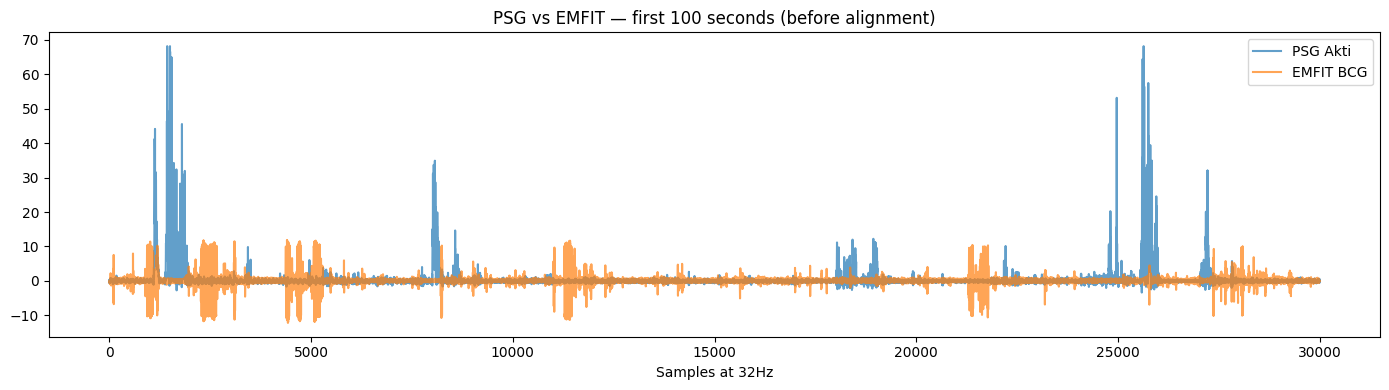

In [53]:
# Z-score normalise both signals
psg_signal = akti['Akti.ext.'].values
psg_norm = (psg_signal - np.nanmean(psg_signal)) / (np.nanstd(psg_signal) + 1e-12)
emfit_norm = (emfit_downsampled - np.nanmean(emfit_downsampled)) / (np.nanstd(emfit_downsampled) + 1e-12)

# Plot a short window of both signals before alignment to visually inspect
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(psg_norm[:30000], label='PSG Akti', alpha=0.7)
ax.plot(emfit_norm[:30000], label='EMFIT BCG', alpha=0.7)
ax.set_title('PSG vs EMFIT — first 100 seconds (before alignment)')
ax.set_xlabel('Samples at 32Hz')
ax.legend()
plt.tight_layout()
plt.show()

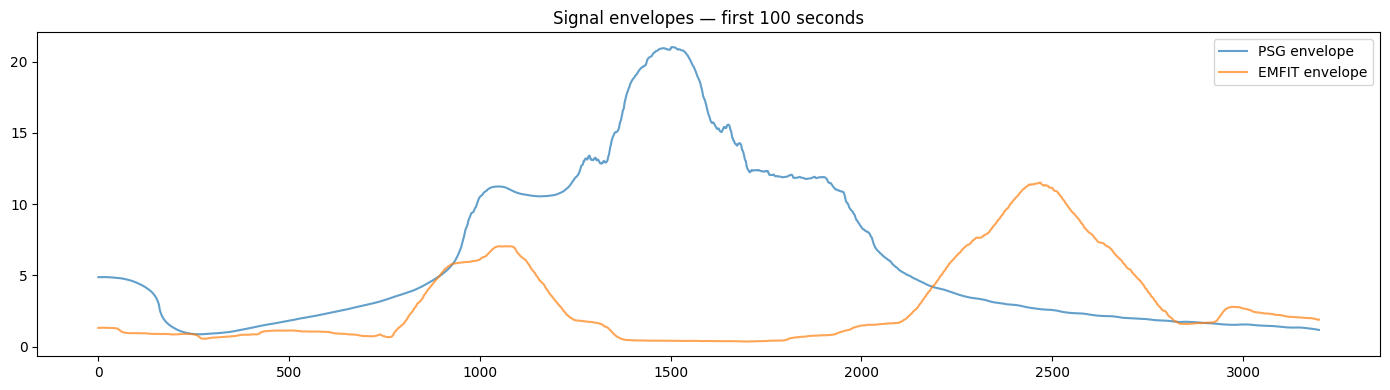

In [54]:
from scipy.signal import hilbert

# Compute signal envelopes using Hilbert transform
psg_envelope = np.abs(hilbert(psg_norm))
emfit_envelope = np.abs(hilbert(emfit_norm))

# Smooth the envelopes
from scipy.ndimage import uniform_filter1d
psg_smooth = uniform_filter1d(psg_envelope, size=320)   # ~10 second window
emfit_smooth = uniform_filter1d(emfit_envelope, size=320)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(psg_smooth[:3200], label='PSG envelope', alpha=0.7)
ax.plot(emfit_smooth[:3200], label='EMFIT envelope', alpha=0.7)
ax.set_title('Signal envelopes — first 100 seconds')
ax.legend()
plt.tight_layout()
plt.show()

Full recording lag: -103.16 seconds


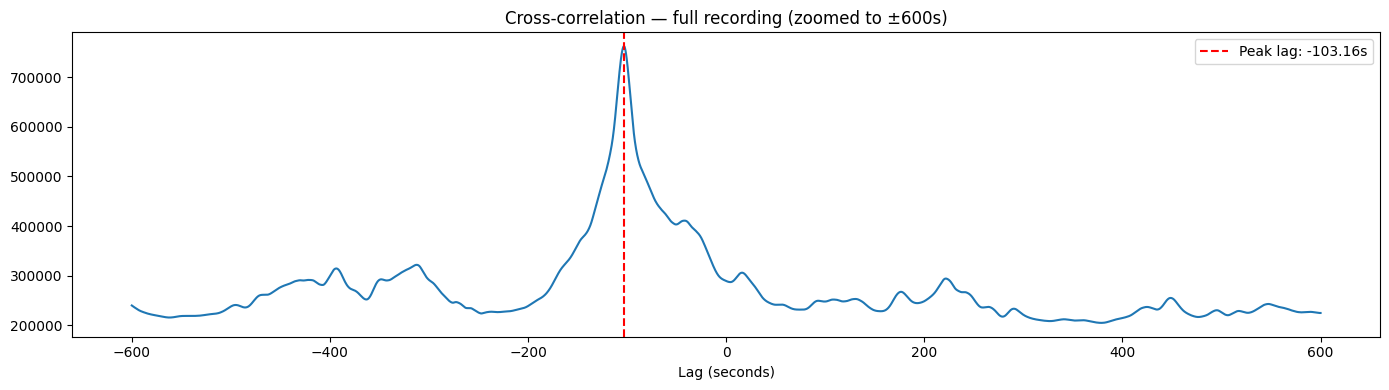

In [55]:
# Cross-correlate full signals
correlation_full = correlate(psg_smooth, emfit_smooth, mode='full')
lags_full = np.arange(-(len(emfit_smooth)-1), len(psg_smooth))

lag_samples_full = lags_full[np.argmax(correlation_full)]
lag_seconds_full = lag_samples_full / 32

print(f"Full recording lag: {lag_seconds_full:.2f} seconds")

# Plot but zoom into ±600 seconds around zero
mask = (lags_full/32 >= -600) & (lags_full/32 <= 600)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lags_full[mask]/32, correlation_full[mask])
ax.axvline(x=lag_seconds_full, color='r', linestyle='--', 
           label=f'Peak lag: {lag_seconds_full:.2f}s')
ax.set_title('Cross-correlation — full recording (zoomed to ±600s)')
ax.set_xlabel('Lag (seconds)')
ax.legend()
plt.tight_layout()
plt.show()

Applying lag of -103.00 seconds (-10300 samples at 100Hz)
lag_seconds: -103.0
lag_samples_100hz: -10300
abs(lag_samples_100hz): 10300
emfit_signal length: 3397100
emfit_aligned length: 3386800
emfit_aligned first 10 values: [-0.000328 -0.000424 -0.0006   -0.000731 -0.000792 -0.000973 -0.000917
 -0.000883 -0.000768 -0.000539]
emfit_aligned_ds length: 1083776
emfit_aligned_envelope first 10 values: [0.99181221 0.99025695 0.98613014 0.98078532 0.97401932 0.96599935
 0.95882687 0.95325494 0.94830304 0.94209785]


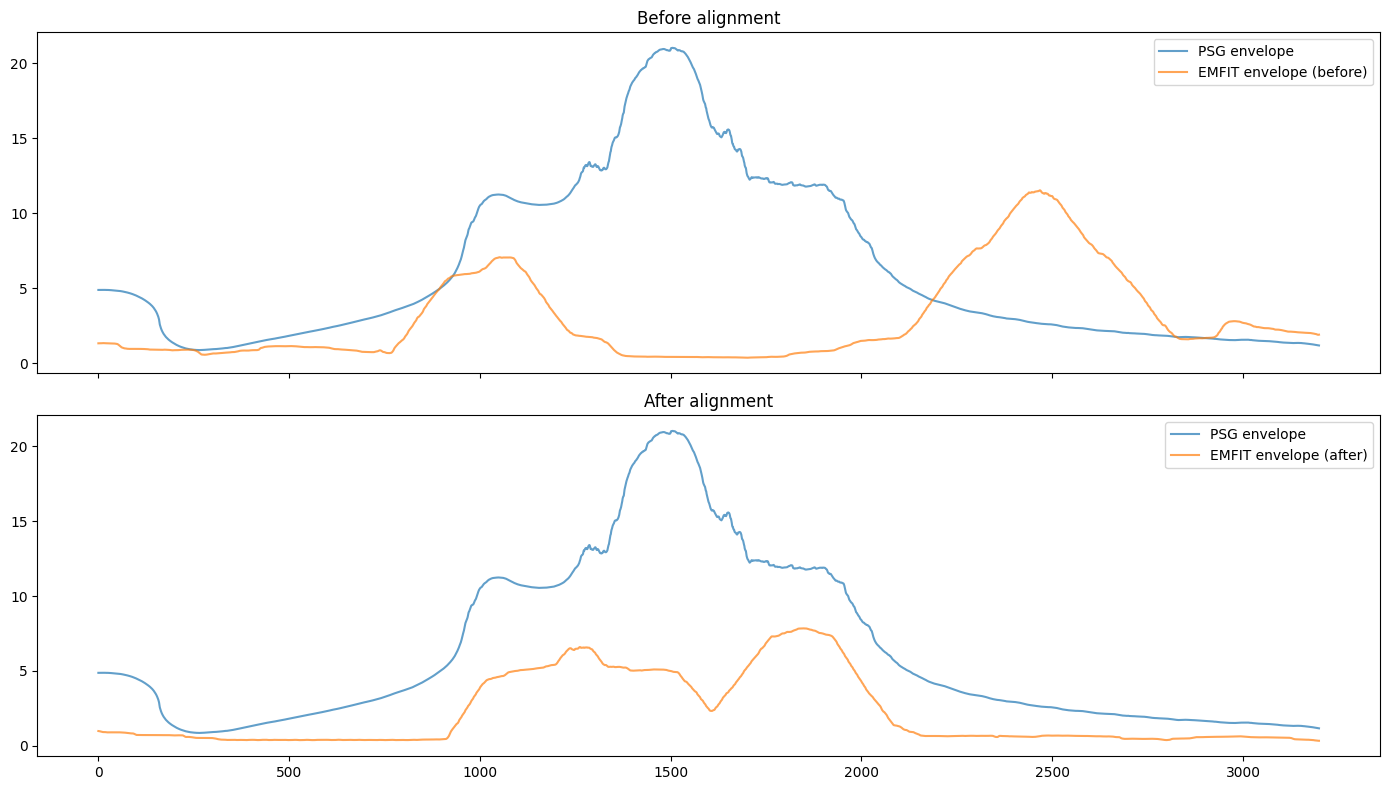

In [56]:
# Apply lag correction
lag_samples_100hz = int(lag_seconds * 100)  # Convert to EMFIT 100Hz samples

print(f"Applying lag of {lag_seconds:.2f} seconds ({lag_samples_100hz} samples at 100Hz)")

# Shift EMFIT signal
if lag_seconds < 0:
    # EMFIT is ahead — trim the start of EMFIT
    emfit_aligned = emfit_signal[abs(lag_samples_100hz):]
else:
    # EMFIT is behind — pad the start
    emfit_aligned = np.pad(emfit_signal, (lag_samples_100hz, 0))

# Downsample aligned signal for plotting
emfit_aligned_ds = resample(emfit_aligned, int(len(emfit_aligned) / downsample_factor))
emfit_aligned_envelope = uniform_filter1d(np.abs(hilbert(emfit_aligned_ds)), size=320)

# Downsample aligned signal for plotting
emfit_aligned_ds = resample(emfit_aligned, int(len(emfit_aligned) / downsample_factor))

# Normalise after resampling
emfit_aligned_ds_norm = (emfit_aligned_ds - np.nanmean(emfit_aligned_ds)) / (np.nanstd(emfit_aligned_ds) + 1e-12)
emfit_aligned_envelope = uniform_filter1d(np.abs(hilbert(emfit_aligned_ds_norm)), size=320)

# Plot comparison
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(psg_smooth[:3200], label='PSG envelope', alpha=0.7)
axs[0].plot(emfit_smooth[:3200], label='EMFIT envelope (before)', alpha=0.7)
axs[0].set_title('Before alignment')
axs[0].legend()

axs[1].plot(psg_smooth[:3200], label='PSG envelope', alpha=0.7)
axs[1].plot(emfit_aligned_envelope[:3200], label='EMFIT envelope (after)', alpha=0.7)
axs[1].set_title('After alignment')
axs[1].legend()

print(f"lag_seconds: {lag_seconds}")
print(f"lag_samples_100hz: {lag_samples_100hz}")
print(f"abs(lag_samples_100hz): {abs(lag_samples_100hz)}")
print(f"emfit_signal length: {len(emfit_signal)}")
print(f"emfit_aligned length: {len(emfit_aligned)}")
print(f"emfit_aligned first 10 values: {emfit_aligned[:10]}")
print(f"emfit_aligned_ds length: {len(emfit_aligned_ds)}")
print(f"emfit_aligned_envelope first 10 values: {emfit_aligned_envelope[:10]}")

plt.tight_layout()
plt.show()

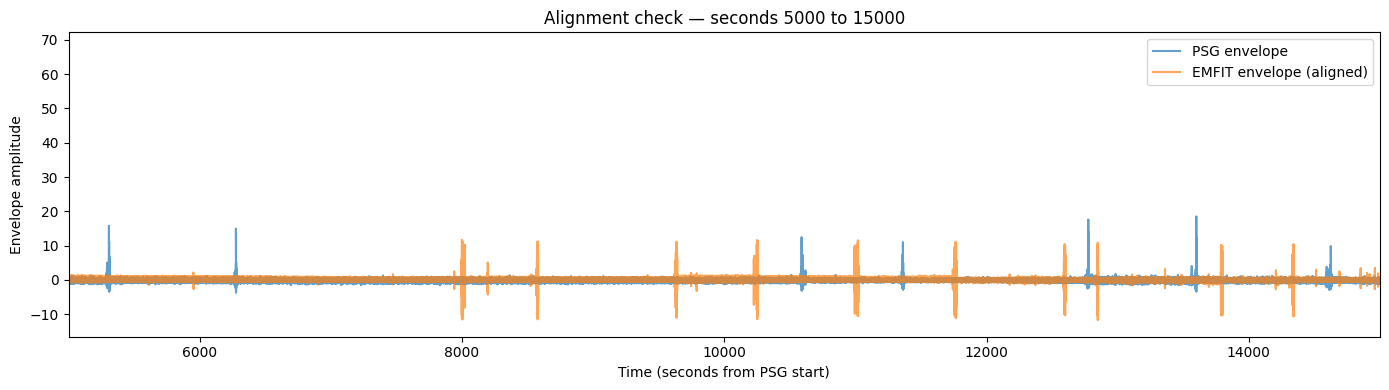

In [59]:
# Convert sample axis to time in seconds from PSG start
psg_duration_seconds = len(psg_norm) / 32
emfit_aligned_duration_minutes = len(emfit_norm) / 32 / 60

time_axis_psg = np.linspace(0, psg_duration_seconds, len(psg_norm))
time_axis_emfit = np.linspace(0, emfit_aligned_duration_seconds, len(emfit_norm))

# Interactive time window selector
start_second = 5000  # change this to explore different parts of the recording
window_seconds = 10000  # how many seconds to show

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(time_axis_psg, psg_norm, label='PSG envelope', alpha=0.7)
ax.plot(time_axis_emfit, emfit_norm, label='EMFIT envelope (aligned)', alpha=0.7)

ax.set_xlim(start_second, start_second + window_seconds)
ax.set_title(f'Alignment check — seconds {start_second} to {start_second + window_seconds}')
ax.set_xlabel('Time (seconds from PSG start)')
ax.set_ylabel('Envelope amplitude')
ax.legend()
plt.tight_layout()
plt.show()